Loading factor returns...


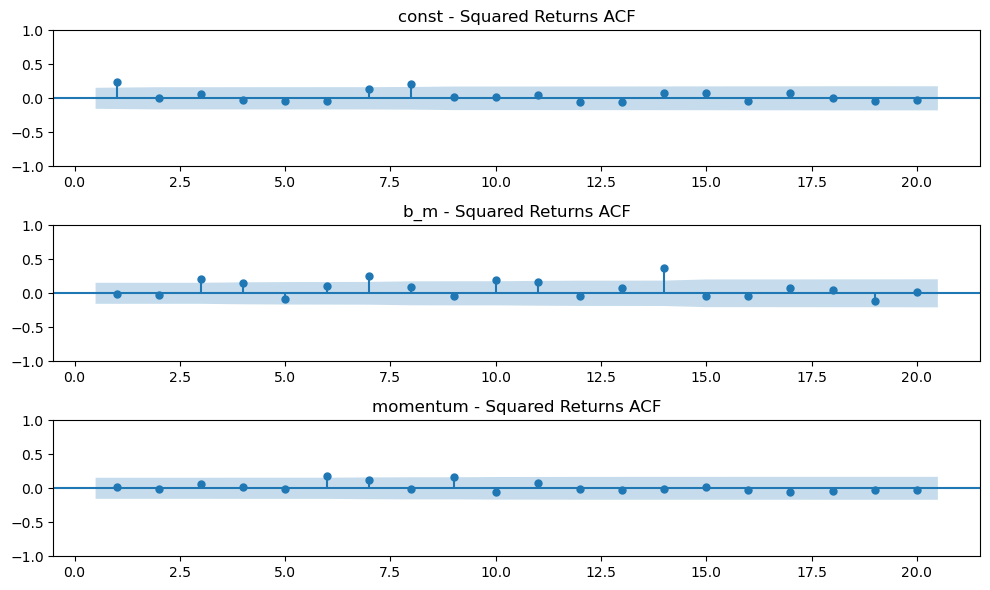

INTERPRETATION: If bars go outside the blue zone, GARCH is required.

=== FITTING GARCH MODELS ===
Training GARCH(1,1) for const...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  const   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -491.284
Distribution:                  Normal   AIC:                           990.568
Method:            Maximum Likelihood   BIC:                           1002.87
                                        No. Observations:                  160
Date:                Thu, Jan 29 2026   Df Residuals:                      159
Time:                        20:09:54   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
-----------

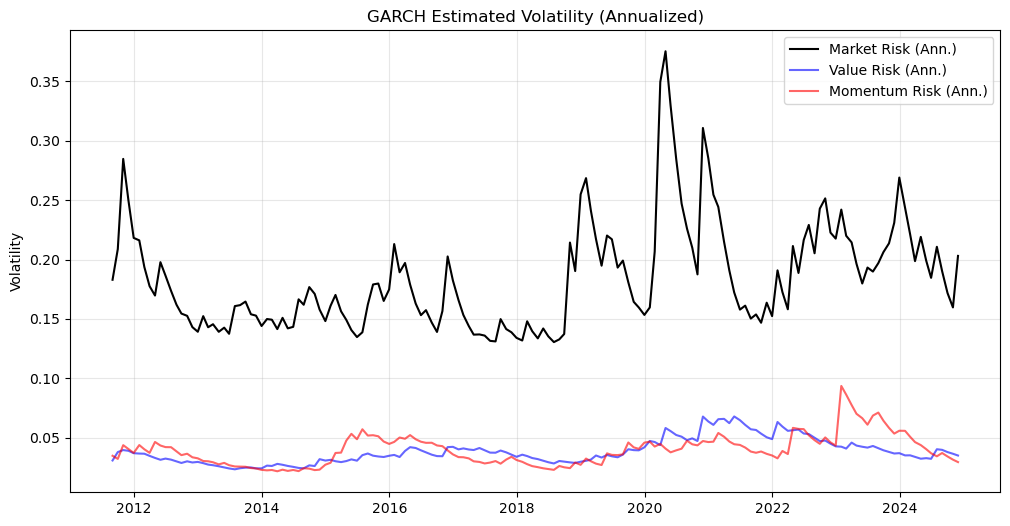

Saved volatility forecasts to data/factor_volatility.parquet


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
import seaborn as sns

# CONFIG
data_path = r"C:\Github Code\quant-factor-engine\data\factor_returns.parquet"

# 1. LOAD DATA
print("Loading factor returns...")
df_factors = pd.read_parquet(data_path)

# We only care about the factors that "Worked" in the regression
# const = Market, b_m = Value, momentum = Reversal Hedge
active_factors = ['const', 'b_m', 'momentum']
df_factors = df_factors[active_factors]

# 2. CHECK FOR ARCH EFFECTS (Case Study 4)
# Before using GARCH, we must prove volatility clusters.
# We look at the ACF of Squared Returns.
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 6))
for i, factor in enumerate(active_factors):
    ax = plt.subplot(3, 1, i+1)
    # Square the returns to see volatility clustering
    plot_acf(df_factors[factor]**2, ax=ax, lags=20, zero=False, title=f'{factor} - Squared Returns ACF')
plt.tight_layout()
plt.show()
print("INTERPRETATION: If bars go outside the blue zone, GARCH is required.")

# 3. FIT GARCH(1,1) MODELS
print("\n=== FITTING GARCH MODELS ===")

vol_forecasts = pd.DataFrame(index=df_factors.index)

for factor in active_factors:
    print(f"Training GARCH(1,1) for {factor}...")
    
    # Scale data by 100 for better convergence (GARCH hates tiny numbers)
    returns_scaled = df_factors[factor] * 100
    
    # Define Model: Constant Mean + GARCH(1,1) Volatility
    model = arch_model(returns_scaled, vol='Garch', p=1, q=1, mean='Constant')
    
    # Fit Model
    res = model.fit(disp='off')
    
    # Print Summary for the "Recruiter Screenshot"
    if factor == 'const': # Only show full summary for Market
        print(res.summary())
    
    # Save the CONDITIONAL VOLATILITY (The Risk Forecast)
    # We divide by 100 to get back to decimal units
    vol_forecasts[factor] = res.conditional_volatility / 100

# 4. PLOT RISK REGIMES
plt.figure(figsize=(12, 6))
plt.plot(vol_forecasts['const'] * np.sqrt(12), label='Market Risk (Ann.)', color='black')
plt.plot(vol_forecasts['b_m'] * np.sqrt(12), label='Value Risk (Ann.)', color='blue', alpha=0.6)
plt.plot(vol_forecasts['momentum'] * np.sqrt(12), label='Momentum Risk (Ann.)', color='red', alpha=0.6)

plt.title('GARCH Estimated Volatility (Annualized)')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. SAVE RISK MODEL
# We need this for the optimizer in the next step
vol_forecasts.to_parquet(r"C:\Github Code\quant-factor-engine\data\factor_volatility.parquet")
print("Saved volatility forecasts to data/factor_volatility.parquet")

Loading data...
Backtesting over 160 months...

=== FINAL PERFORMANCE (2011-2024) ===
Strategy Total Return: 88.46%
Market Total Return:   634.31%
Strategy Sharpe: 0.70
Market Sharpe:   0.89


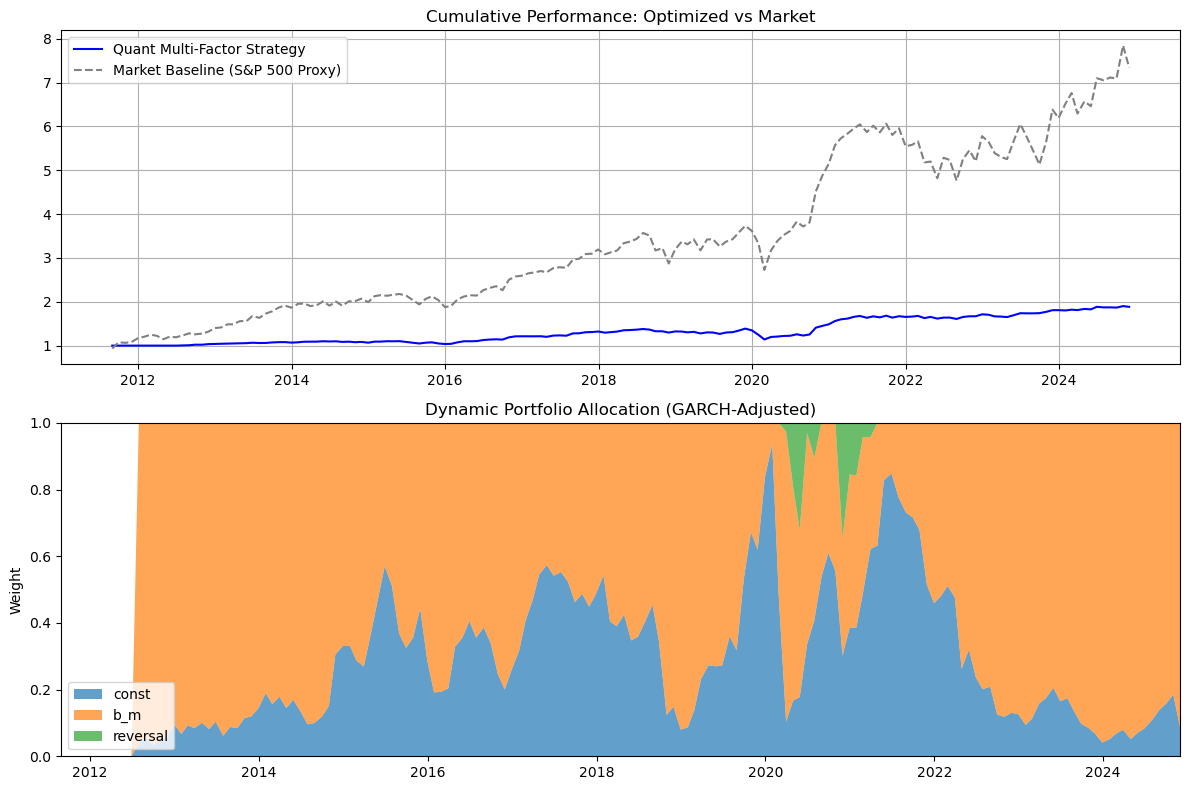

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# CONFIG
ret_path = r"C:\Github Code\quant-factor-engine\data\factor_returns.parquet"
vol_path = r"C:\Github Code\quant-factor-engine\data\factor_volatility.parquet"

# 1. LOAD DATA
print("Loading data...")
returns = pd.read_parquet(ret_path)
vols = pd.read_parquet(vol_path)

# Filter for our 3 Key Assets
factors = ['const', 'b_m', 'momentum']
returns = returns[factors].dropna()
vols = vols[factors].dropna()

# 2. INVERT MOMENTUM (Create "Reversal" Factor)
# Since Momentum loses money, we flip the sign to make it a profitable "Long" asset.
returns['momentum'] = -1 * returns['momentum']
returns.rename(columns={'momentum': 'reversal'}, inplace=True)
vols.rename(columns={'momentum': 'reversal'}, inplace=True)
factors = ['const', 'b_m', 'reversal']

# Align dates (Intersection of GARCH and Returns)
common_dates = returns.index.intersection(vols.index)
returns = returns.loc[common_dates]
vols = vols.loc[common_dates]

print(f"Backtesting over {len(returns)} months...")

# 3. DEFINE OPTIMIZER FUNCTIONS
# We want to Maximize Sharpe = (Mean Return) / (Portfolio Volatility)
# Scipy minimizes, so we Minimize (-Sharpe)

def get_portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

def neg_sharpe_ratio(weights, exp_ret, cov_matrix):
    port_ret = np.dot(weights, exp_ret)
    port_vol = np.sqrt(get_portfolio_variance(weights, cov_matrix))
    # Add small epsilon to avoid division by zero
    return -(port_ret / (port_vol + 1e-6))

# 4. WALK-FORWARD BACKTEST LOOP
portfolio_returns = []
weights_history = []

# Constant Correlation Assumption (Simplification for Robustness)
# We use the full sample correlation, but dynamic GARCH volatility.
# Correlation is usually more stable than volatility.
corr_matrix = returns.corr()

# Loop through each month
for date in returns.index:
    
    # A. INPUTS FOR THIS MONTH
    # 1. Expected Return: Expanding Window Average (No Look-Ahead Bias!)
    # We use all data UP TO this date to estimate the mean.
    # Note: For the first few months, this might be noisy.
    past_data = returns.loc[:date]
    if len(past_data) < 12: # Skip first year to build sample
        portfolio_returns.append(0)
        weights_history.append([0,0,0])
        continue
        
    mu = past_data.mean().values
    
    # 2. Covariance Matrix: D * R * D
    # D = Diagonal matrix of GARCH volatilities for this specific month
    current_vol = vols.loc[date].values
    D = np.diag(current_vol)
    sigma = np.dot(D, np.dot(corr_matrix, D))
    
    # B. OPTIMIZATION
    # Constraints: Fully Invested (Sum weights = 1), Long Only (0 <= w <= 1)
    # Long Only is safer for student projects (no margin calls).
    n_assets = len(factors)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n_assets))
    init_guess = [1/n_assets] * n_assets
    
    result = minimize(neg_sharpe_ratio, init_guess, args=(mu, sigma),
                      method='SLSQP', bounds=bounds, constraints=constraints)
    
    # Store Optimal Weights
    opt_weights = result.x
    weights_history.append(opt_weights)
    
    # C. EXECUTION (Calculate return for this month)
    # We hold these weights for the month. 
    # Note: In reality, you calculate weights at t-1 and earn return at t.
    # Since our 'returns' df implies return realized at 'date', we apply weights to THIS row.
    ret_month = np.dot(opt_weights, returns.loc[date].values)
    portfolio_returns.append(ret_month)

# 5. PERFORMANCE ANALYSIS
strategy_ret = pd.Series(portfolio_returns, index=returns.index)
market_ret = returns['const'] # The baseline

# Cumulative Wealth
wealth_strat = (1 + strategy_ret).cumprod()
wealth_mkt = (1 + market_ret).cumprod()

print("\n=== FINAL PERFORMANCE (2011-2024) ===")
print(f"Strategy Total Return: {(wealth_strat.iloc[-1]-1):.2%}")
print(f"Market Total Return:   {(wealth_mkt.iloc[-1]-1):.2%}")

# Annualized Volatility
vol_strat = strategy_ret.std() * np.sqrt(12)
vol_mkt = market_ret.std() * np.sqrt(12)

# Sharpe Ratio (assuming 0% risk free for simplicity)
sharpe_strat = (strategy_ret.mean() * 12) / vol_strat
sharpe_mkt = (market_ret.mean() * 12) / vol_mkt

print(f"Strategy Sharpe: {sharpe_strat:.2f}")
print(f"Market Sharpe:   {sharpe_mkt:.2f}")

# 6. PLOTTING
plt.figure(figsize=(12, 8))

# Subplot 1: Wealth Curve
plt.subplot(2, 1, 1)
plt.plot(wealth_strat, label='Quant Multi-Factor Strategy', color='blue')
plt.plot(wealth_mkt, label='Market Baseline (S&P 500 Proxy)', color='grey', linestyle='--')
plt.title('Cumulative Performance: Optimized vs Market')
plt.legend()
plt.grid(True)

# Subplot 2: Dynamic Weights (The "Cool" Chart)
plt.subplot(2, 1, 2)
weights_df = pd.DataFrame(weights_history, index=returns.index, columns=factors)
plt.stackplot(weights_df.index, weights_df.T, labels=factors, alpha=0.7)
plt.title('Dynamic Portfolio Allocation (GARCH-Adjusted)')
plt.ylabel('Weight')
plt.legend(loc='lower left')
plt.margins(0,0)

plt.tight_layout()
plt.show()